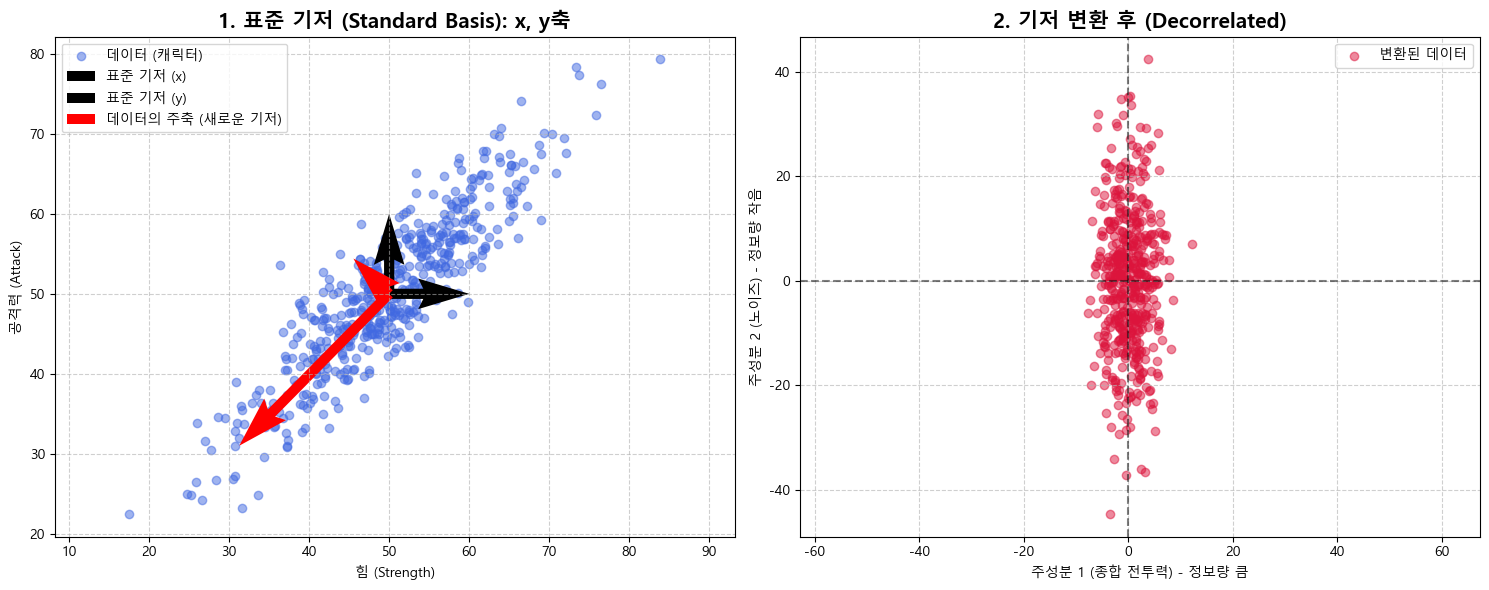

In [2]:
'''
[MML 2장 발표용 시각화 자료]
주제: 기저 변환을 통한 선형 종속성 제거와 특징 추출 (PCA의 기초)
데이터: 강한 양의 상관관계를 가진 가상의 게임 캐릭터 스탯 (힘 vs 공격력)

이 코드는 다음 과정을 보여줍니다:
1. 데이터 생성: 대각선으로 찌그러진 타원형 데이터 (변수 간 종속성 존재)
2. 표준 기저(Standard Basis): 우리가 흔히 쓰는 x, y축
3. 고유 기저(Eigen Basis): 데이터의 분산이 가장 큰 방향을 찾은 새로운 축
4. 기저 변환: 데이터를 새로운 축에 맞춰 회전시켜 독립적인 성분으로 분리
'''

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] ='Malgun Gothic'
plt.rcParams['axes.unicode_minus'] =False

# 1. 데이터 생성 (가상의 게임 캐릭터 500명)
np.random.seed(42)
mean = [50, 50]  # 평균 (힘 50, 공격력 50)
# 공분산 행렬 [[분산X, 공분산], [공분산, 분산Y]]
# 공분산을 높게 설정하여 강한 상관관계(대각선 분포)를 만듦
cov = [[100, 90], 
       [90, 100]] 

data = np.random.multivariate_normal(mean, cov, 500).T
x, y = data

# 2. 데이터의 주요 축(주성분) 계산 - PCA 원리
# 공분산 행렬의 고유값과 고유벡터를 구합니다.
# 고유벡터(eigenvectors)가 바로 우리가 찾던 '새로운 기저'입니다.
cov_matrix = np.cov(x, y)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 시각화 준비
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- 첫 번째 그래프: 표준 기저 (Original Basis) ---
ax[0].scatter(x, y, alpha=0.5, color='royalblue', label='데이터 (캐릭터)')
ax[0].set_title("1. 표준 기저 (Standard Basis): x, y축", fontsize=15, fontweight='bold')
ax[0].set_xlabel("힘 (Strength)")
ax[0].set_ylabel("공격력 (Attack)")
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].axis('equal')

# 표준 기저 벡터 그리기 (검은색 화살표)
origin = [50, 50] # 화살표 시작점 (평균 위치)
ax[0].quiver(*origin, 10, 0, color='k', scale=1, scale_units='xy', angles='xy', width=0.015, label='표준 기저 (x)')
ax[0].quiver(*origin, 0, 10, color='k', scale=1, scale_units='xy', angles='xy', width=0.015, label='표준 기저 (y)')

# 데이터의 방향성(새로운 기저) 표시 (빨간색 화살표)
# 고유벡터의 크기를 고유값(분산)에 비례하게 시각화
v1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0]) * 2
v2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1]) * 2

ax[0].quiver(*origin, *v1, color='r', scale=1, scale_units='xy', angles='xy', width=0.015, label='데이터의 주축 (새로운 기저)')
ax[0].quiver(*origin, *v2, color='r', scale=1, scale_units='xy', angles='xy', width=0.015)
ax[0].legend()


# --- 두 번째 그래프: 기저 변환 후 (Transformed Basis) ---
# 데이터를 새로운 기저(고유벡터) 공간으로 투영(Projection)
# P_inv * X (행렬 곱을 통해 좌표계를 회전시킴)
projection_matrix = eigenvectors.T 
transformed_data = projection_matrix @ (data - np.array(mean).reshape(2,1))

ax[1].scatter(transformed_data[0], transformed_data[1], alpha=0.5, color='crimson', label='변환된 데이터')
ax[1].set_title("2. 기저 변환 후 (Decorrelated)", fontsize=15, fontweight='bold')
ax[1].set_xlabel("주성분 1 (종합 전투력) - 정보량 큼")
ax[1].set_ylabel("주성분 2 (노이즈) - 정보량 작음")
ax[1].axhline(0, color='k', linestyle='--', alpha=0.5)
ax[1].axvline(0, color='k', linestyle='--', alpha=0.5)
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].axis('equal')
ax[1].legend()

plt.tight_layout()
plt.show()

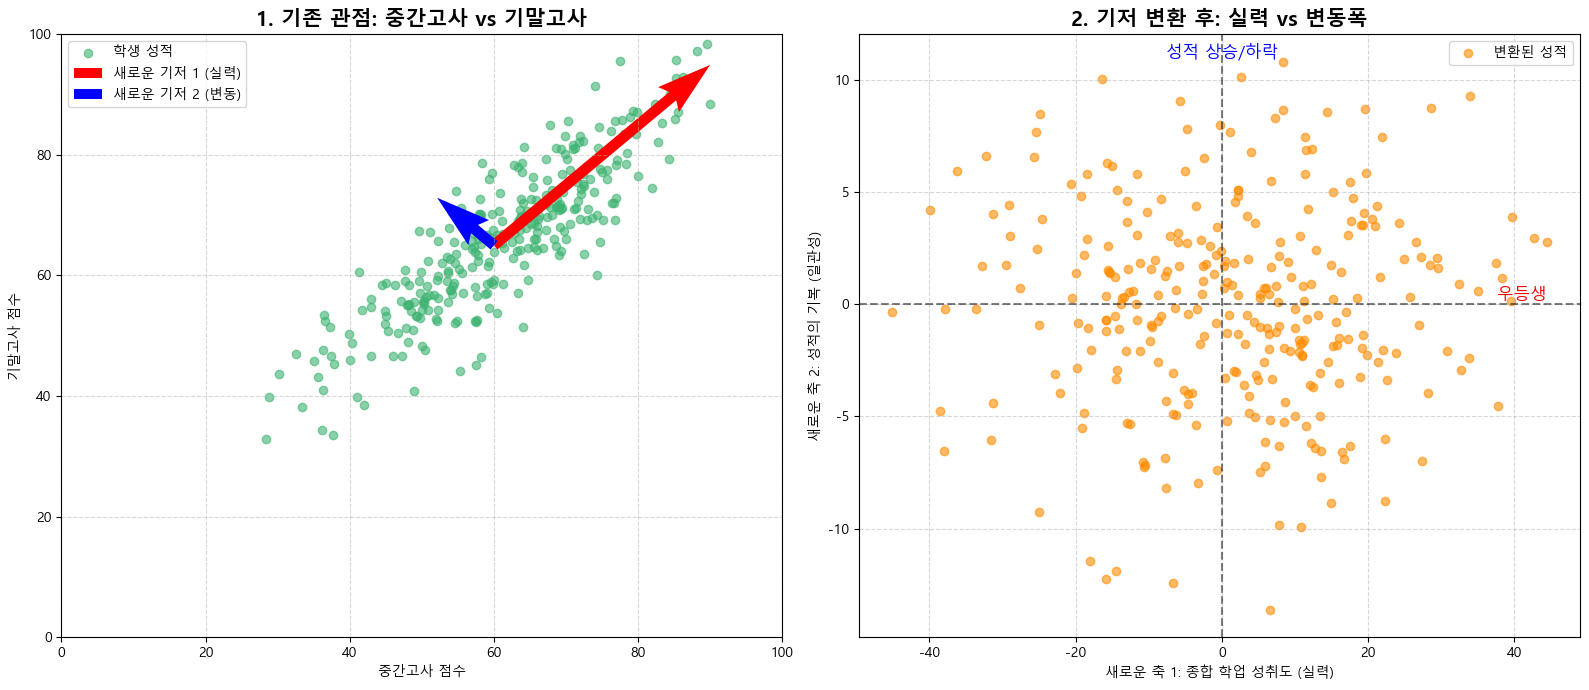

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 데이터 생성 (학생 300명의 성적)
np.random.seed(0)
# 평균: 중간 60점, 기말 65점 (기말이 조금 더 어려웠거나 쉬웠을 수 있음)
mean = [60, 65] 
# 공분산: 둘 사이의 상관관계가 매우 높음 (중간 잘보면 기말도 잘봄)
cov = [[150, 130], 
       [130, 150]] 

data = np.random.multivariate_normal(mean, cov, 300).T
midterm, final = data

# 데이터 범위 0~100점으로 클리핑 (현실성 부여)
midterm = np.clip(midterm, 0, 100)
final = np.clip(final, 0, 100)

# 2. PCA (기저 변환) 계산
data_stack = np.vstack([midterm, final])
cov_matrix = np.cov(data_stack)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 고유값이 큰 순서대로 정렬 (주성분 1, 2 순서)
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# 기저 변환 (데이터 회전)
transformed_data = eigenvectors.T @ (data_stack - np.array(mean).reshape(2,1))


# 3. 시각화
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- (1) 원래 관점: 중간고사 vs 기말고사 ---
ax[0].scatter(midterm, final, alpha=0.6, color='mediumseagreen', label='학생 성적')
ax[0].set_title("1. 기존 관점: 중간고사 vs 기말고사", fontsize=15, fontweight='bold')
ax[0].set_xlabel("중간고사 점수")
ax[0].set_ylabel("기말고사 점수")
ax[0].set_xlim(0, 100)
ax[0].set_ylim(0, 100)
ax[0].grid(True, linestyle='--', alpha=0.5)

# 주축(Eigenvector) 표시
origin = [60, 65]
# 주성분 1 (종합 실력 방향)
v1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0]) * 2.5 
# 주성분 2 (성적 변동 방향)
v2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1]) * 2.5 

ax[0].quiver(*origin, *v1, color='r', scale=1, scale_units='xy', angles='xy', width=0.015, label='새로운 기저 1 (실력)')
ax[0].quiver(*origin, *v2, color='b', scale=1, scale_units='xy', angles='xy', width=0.015, label='새로운 기저 2 (변동)')
ax[0].legend()


# --- (2) 변환된 관점: 종합 실력 vs 성적 기복 ---
ax[1].scatter(transformed_data[0], transformed_data[1], alpha=0.6, color='darkorange', label='변환된 성적')
ax[1].set_title("2. 기저 변환 후: 실력 vs 변동폭", fontsize=15, fontweight='bold')
ax[1].set_xlabel("새로운 축 1: 종합 학업 성취도 (실력)")
ax[1].set_ylabel("새로운 축 2: 성적의 기복 (일관성)")
ax[1].axhline(0, color='k', linestyle='--', alpha=0.5)
ax[1].axvline(0, color='k', linestyle='--', alpha=0.5)
ax[1].grid(True, linestyle='--', alpha=0.5)

# 설명 텍스트 추가
ax[1].text(0, max(transformed_data[1]), "성적 상승/하락", ha='center', va='bottom', fontsize=12, color='blue')
ax[1].text(max(transformed_data[0]), 0, "우등생", ha='right', va='bottom', fontsize=12, color='red')
ax[1].legend()

plt.tight_layout()
plt.show()

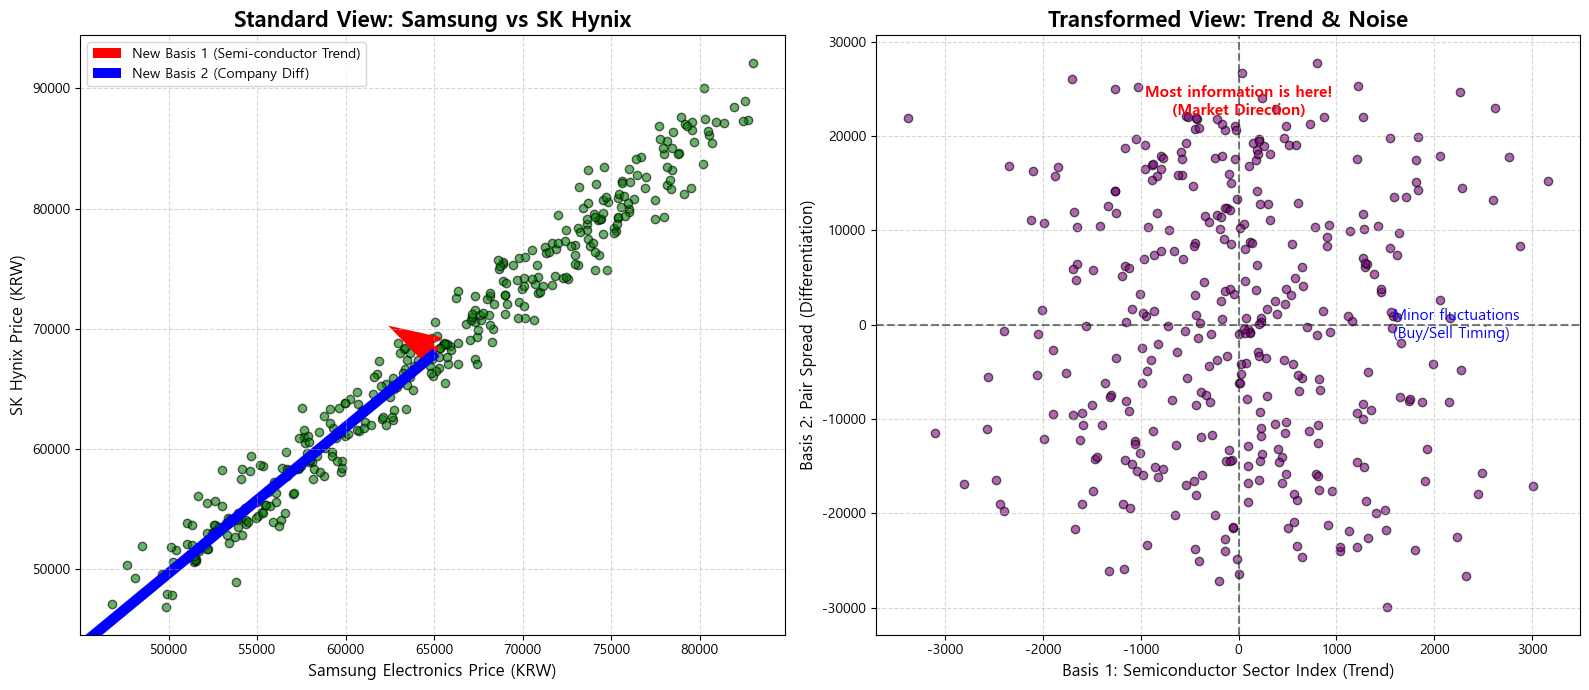

In [5]:
'''
[MML 2장 발표용: 주식 데이터 기저 변환]
주제: 삼성전자와 SK하이닉스 주가의 상관관계와 기저 변환
목표: 두 주식의 움직임을 '반도체 업황(Trend)'과 '개별 차이(Spread)'로 분리하여 본다.
'''

import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Colab이나 로컬 환경에 맞게 조정 필요, 여기서는 영문으로 표기)
# plt.rc('font', family='NanumBarunGothic') 

# 1. 가상의 주가 데이터 생성 (365일)
np.random.seed(10)
days = 365

# 공통된 시장 요인 (반도체 업황) - 우상향 트렌드
market_trend = np.linspace(50000, 80000, days) + np.random.normal(0, 2000, days)

# 삼성전자: 시장 요인 + 삼성만의 노이즈
samsung = market_trend + np.random.normal(0, 1000, days)
# SK하이닉스: 시장 요인 * 1.2 (변동성 더 큼) + 하이닉스만의 노이즈
sk_hynix = (market_trend * 1.2) + np.random.normal(0, 1500, days) - 10000 # 가격대 조정

# 데이터 행렬 만들기
data = np.vstack([samsung, sk_hynix])
mean_prices = np.mean(data, axis=1).reshape(2, 1)

# 2. PCA를 이용한 기저 찾기 (주성분 분석)
cov_matrix = np.cov(data)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 시각화
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- 그래프 1: 우리가 보는 HTS 화면 (표준 기저) ---
ax[0].scatter(samsung, sk_hynix, alpha=0.6, c='green', edgecolors='k')
ax[0].set_title("Standard View: Samsung vs SK Hynix", fontsize=16, fontweight='bold')
ax[0].set_xlabel("Samsung Electronics Price (KRW)", fontsize=12)
ax[0].set_ylabel("SK Hynix Price (KRW)", fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.5)

# 주성분 벡터 표시
origin = mean_prices
v1 = eigenvectors[:, 0] * np.sqrt(eigenvalues[0]) * 3 # 시각적 강조를 위해 스케일 조정
v2 = eigenvectors[:, 1] * np.sqrt(eigenvalues[1]) * 3

ax[0].quiver(*origin, *v1, color='r', scale=1, scale_units='xy', angles='xy', width=0.015, label='New Basis 1 (Semi-conductor Trend)')
ax[0].quiver(*origin, *v2, color='b', scale=1, scale_units='xy', angles='xy', width=0.015, label='New Basis 2 (Company Diff)')
ax[0].legend(loc='upper left')


# --- 그래프 2: 투자의 고수가 보는 화면 (변환된 기저) ---
# 기저 변환 수행 (데이터 회전)
projection_matrix = eigenvectors.T
transformed_data = projection_matrix @ (data - mean_prices)

ax[1].scatter(transformed_data[0], transformed_data[1], alpha=0.6, c='purple', edgecolors='k')
ax[1].set_title("Transformed View: Trend & Noise", fontsize=16, fontweight='bold')
ax[1].set_xlabel("Basis 1: Semiconductor Sector Index (Trend)", fontsize=12)
ax[1].set_ylabel("Basis 2: Pair Spread (Differentiation)", fontsize=12)
ax[1].axhline(0, color='k', linestyle='--', alpha=0.5)
ax[1].axvline(0, color='k', linestyle='--', alpha=0.5)
ax[1].grid(True, linestyle='--', alpha=0.5)

# 설명 텍스트 추가
ax[1].text(0, max(transformed_data[1])*0.8, "Most information is here!\n(Market Direction)", 
           ha='center', color='red', fontsize=11, fontweight='bold')
ax[1].text(max(transformed_data[0])*0.5, 0, "Minor fluctuations\n(Buy/Sell Timing)", 
           va='center', color='blue', fontsize=11)

plt.tight_layout()
plt.show()

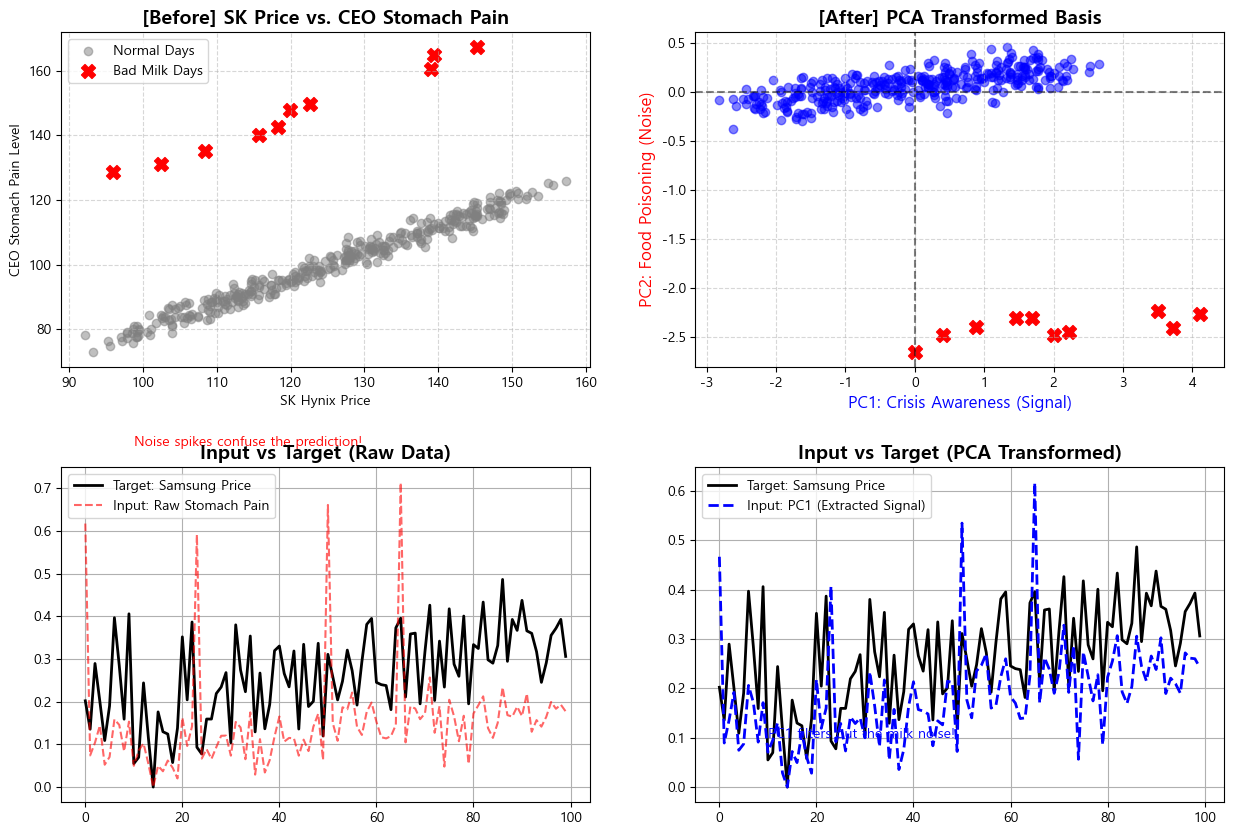

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. 가상의 세계관 설정 (365일)
np.random.seed(42)
days = 365
time = np.arange(days)

# (1) SK 하이닉스 주가 (x1): 시장 상황에 따라 변동
# 우상향 트렌드 + 랜덤 변동
sk_price = np.linspace(100, 150, days) + np.random.normal(0, 5, days)

# (2) 이재용 회장의 '진짜 위기 의식' (Latent Variable - 잠재 변수)
# SK가 오르면 위기감을 느낌 (SK 주가와 밀접한 연관)
true_crisis_feeling = sk_price * 0.8 + np.random.normal(0, 2, days)

# (3) 노이즈 추가: '상한 우유' 사건 (Bad Milk Event)
# 가끔씩 SK 주가와 상관없이 배가 아픔 (이상치 발생)
food_poisoning = np.zeros(days)
# 1년 중 10번 정도 상한 우유를 마심 (복통 수치 급증)
poison_days = np.random.choice(days, 10, replace=False)
food_poisoning[poison_days] = 50  # 복통 수치 +50 (엄청 아픔)

# (4) 관측된 '회장님 복통 지수' (x2)
# 우리가 실제 볼 수 있는 건 (진짜 위기감 + 상한 우유) 합쳐진 결과
observed_stomach_pain = true_crisis_feeling + food_poisoning

# (5) 삼성전자 주가 (y - Target)
# 삼성 주가는 오직 '진짜 위기 의식(경쟁심)'에만 반응해서 오름
# 상한 우유(food_poisoning) 때문에 아픈 건 주가에 영향 없음
samsung_price = true_crisis_feeling * 1.5 + np.random.normal(0, 5, days)

# ---------------------------------------------------------
# 2. 엔지니어의 분석: 기저 변환 (PCA)
# ---------------------------------------------------------

# 데이터 전처리: SK주가와 복통지수를 하나의 행렬로 만듦
X = np.column_stack((sk_price, observed_stomach_pain))

# 스케일링 (단위가 다르므로 정규화 필수)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA 수행 (2차원 -> 2차원 기저 변환)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# PC1: 제1주성분 (데이터의 가장 큰 분산 방향) -> "경쟁심(Stimulation)"
# PC2: 제2주성분 (나머지 직교 방향) -> "노이즈(Bad Milk)"
pc1_stimulation = X_pca[:, 0]
pc2_noise = X_pca[:, 1]


# ---------------------------------------------------------
# 3. 시각화: 결과 분석
# ---------------------------------------------------------
fig, ax = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(hspace=0.3)

# [그래프 1] 원본 데이터 분포 (SK 주가 vs 복통)
ax[0, 0].scatter(sk_price, observed_stomach_pain, c='gray', alpha=0.5, label='Normal Days')
ax[0, 0].scatter(sk_price[poison_days], observed_stomach_pain[poison_days], c='red', s=100, marker='X', label='Bad Milk Days')
ax[0, 0].set_title("[Before] SK Price vs. CEO Stomach Pain", fontsize=14, fontweight='bold')
ax[0, 0].set_xlabel("SK Hynix Price")
ax[0, 0].set_ylabel("CEO Stomach Pain Level")
ax[0, 0].legend()
ax[0, 0].grid(True, linestyle='--', alpha=0.5)

# [그래프 2] 기저 변환 후 분포 (PC1 vs PC2)
ax[0, 1].scatter(pc1_stimulation, pc2_noise, c='blue', alpha=0.5, label='Normal Data')
ax[0, 1].scatter(pc1_stimulation[poison_days], pc2_noise[poison_days], c='red', s=100, marker='X', label='Outliers (Bad Milk)')
ax[0, 1].set_title("[After] PCA Transformed Basis", fontsize=14, fontweight='bold')
ax[0, 1].set_xlabel("PC1: Crisis Awareness (Signal)", fontsize=12, color='blue')
ax[0, 1].set_ylabel("PC2: Food Poisoning (Noise)", fontsize=12, color='red')
ax[0, 1].axhline(0, color='k', linestyle='--', alpha=0.5)
ax[0, 1].axvline(0, color='k', linestyle='--', alpha=0.5)
ax[0, 1].grid(True, linestyle='--', alpha=0.5)

# [그래프 3] 삼성전자 주가와 변수들의 상관관계 비교 (Time Series)
# 보기 쉽게 정규화하여 비교
def normalize(v): return (v - v.min()) / (v.max() - v.min())

ax[1, 0].plot(time[:100], normalize(samsung_price)[:100], 'k-', linewidth=2, label='Target: Samsung Price')
ax[1, 0].plot(time[:100], normalize(observed_stomach_pain)[:100], 'r--', alpha=0.6, label='Input: Raw Stomach Pain')
ax[1, 0].set_title("Input vs Target (Raw Data)", fontsize=14, fontweight='bold')
ax[1, 0].legend()
ax[1, 0].grid(True)
ax[1, 0].text(10, 0.8, "Noise spikes confuse the prediction!", color='red')

# [그래프 4] 삼성전자 주가와 PC1(주성분) 비교
# 방향(부호)을 맞추기 위해 상관계수 체크 후 flip
if np.corrcoef(samsung_price, pc1_stimulation)[0,1] < 0: pc1_stimulation = -pc1_stimulation

ax[1, 1].plot(time[:100], normalize(samsung_price)[:100], 'k-', linewidth=2, label='Target: Samsung Price')
ax[1, 1].plot(time[:100], normalize(pc1_stimulation)[:100], 'b--', linewidth=2, label='Input: PC1 (Extracted Signal)')
ax[1, 1].set_title("Input vs Target (PCA Transformed)", fontsize=14, fontweight='bold')
ax[1, 1].legend()
ax[1, 1].grid(True)
ax[1, 1].text(10, 0.1, "PC1 filters out the milk noise!", color='blue')

plt.show()

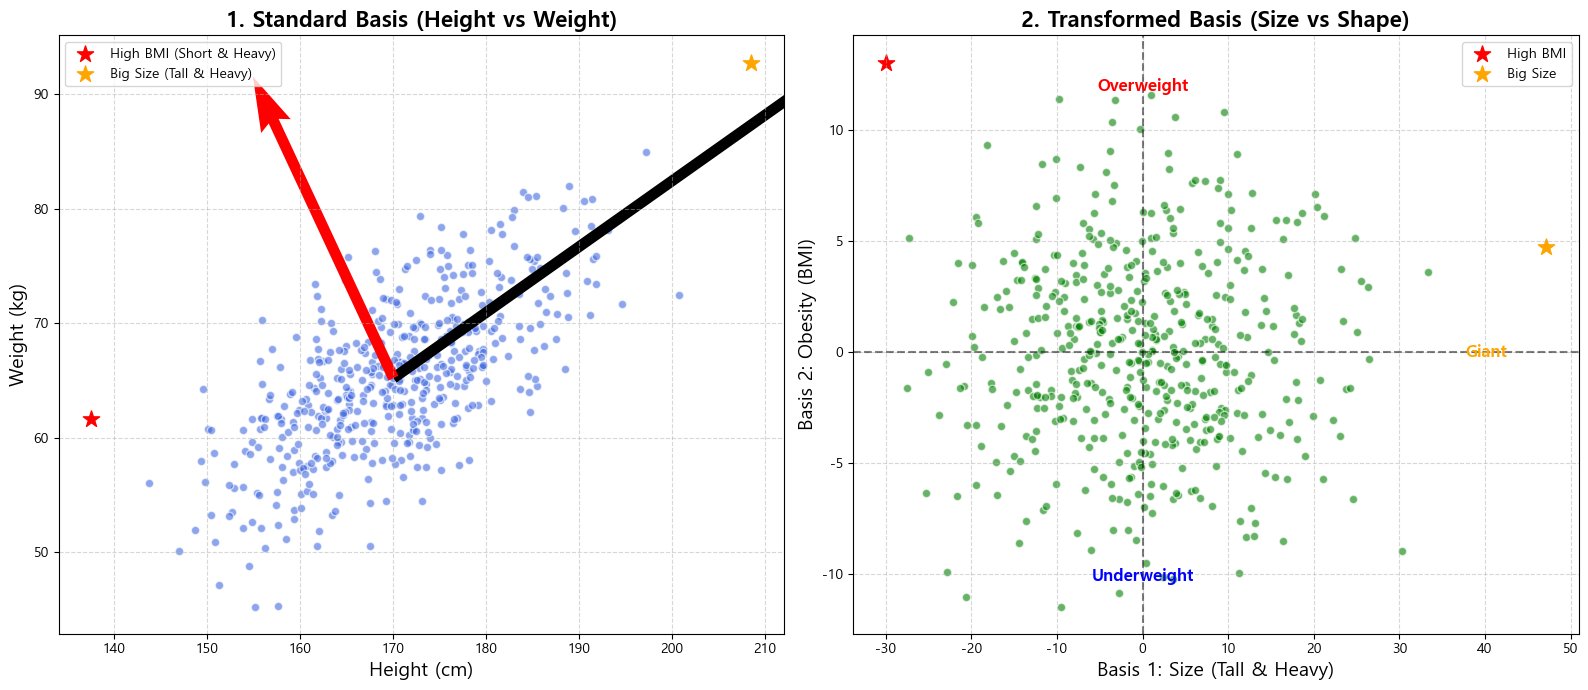

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. 가상의 키/몸무게 데이터 생성 (500명)
np.random.seed(42)
n_samples = 500

# 키 (150cm ~ 190cm)
height = np.random.normal(170, 10, n_samples)
# 몸무게: 키에 비례(0.5배) + 개인차(노이즈)
weight = (height * 0.5 - 20) + np.random.normal(0, 5, n_samples)

# 데이터 행렬
X = np.column_stack((height, weight))

# 2. PCA (기저 변환) 수행
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 변환된 데이터 (PC1: 덩치, PC2: 비만도)
size = X_pca[:, 0]
bmi_shape = X_pca[:, 1]

# ---------------------------------------------------------
# 시각화
# ---------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# [그래프 1] 표준 기저 (키 vs 몸무게)
ax[0].scatter(height, weight, alpha=0.6, c='royalblue', edgecolors='w')
ax[0].set_title("1. Standard Basis (Height vs Weight)", fontsize=16, fontweight='bold')
ax[0].set_xlabel("Height (cm)", fontsize=14)
ax[0].set_ylabel("Weight (kg)", fontsize=14)
ax[0].grid(True, linestyle='--', alpha=0.5)

# 특정 데이터 포인트 강조 (예: 키 작고 무거운 사람 vs 키 크고 무거운 사람)
p1_idx = np.argmax(bmi_shape) # 비만도가 가장 높은 사람
p2_idx = np.argmax(size)      # 덩치가 가장 큰 사람 (키 크고 무게 많이 나감)

ax[0].scatter(height[p1_idx], weight[p1_idx], c='red', s=150, marker='*', label='High BMI (Short & Heavy)')
ax[0].scatter(height[p2_idx], weight[p2_idx], c='orange', s=150, marker='*', label='Big Size (Tall & Heavy)')
ax[0].legend()

# 주성분 벡터 표시
origin = [np.mean(height), np.mean(weight)]
scale = 7
v1 = pca.components_[0] * scale * np.sqrt(pca.explained_variance_[0])
v2 = pca.components_[1] * scale * np.sqrt(pca.explained_variance_[1])

ax[0].quiver(*origin, *v1, color='k', scale=1, scale_units='xy', angles='xy', width=0.015, label='New Basis 1 (Size)')
ax[0].quiver(*origin, *v2, color='r', scale=1, scale_units='xy', angles='xy', width=0.015, label='New Basis 2 (Obesity)')


# [그래프 2] 변환된 기저 (덩치 vs 비만도)
# 시각적 직관을 위해 90도 회전된 형태로 보여줌
ax[1].scatter(size, bmi_shape, alpha=0.6, c='green', edgecolors='w')
ax[1].set_title("2. Transformed Basis (Size vs Shape)", fontsize=16, fontweight='bold')
ax[1].set_xlabel("Basis 1: Size (Tall & Heavy)", fontsize=14)
ax[1].set_ylabel("Basis 2: Obesity (BMI)", fontsize=14)
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].axhline(0, color='k', linestyle='--', alpha=0.5)
ax[1].axvline(0, color='k', linestyle='--', alpha=0.5)

# 같은 사람을 새로운 좌표계에서 표시
ax[1].scatter(size[p1_idx], bmi_shape[p1_idx], c='red', s=150, marker='*', label='High BMI')
ax[1].scatter(size[p2_idx], bmi_shape[p2_idx], c='orange', s=150, marker='*', label='Big Size')

# 설명 텍스트
ax[1].text(0, max(bmi_shape)*0.9, "Overweight", ha='center', color='red', fontsize=12, fontweight='bold')
ax[1].text(0, min(bmi_shape)*0.9, "Underweight", ha='center', color='blue', fontsize=12, fontweight='bold')
ax[1].text(max(size)*0.8, 0, "Giant", va='center', color='orange', fontsize=12, fontweight='bold')

ax[1].legend()

plt.tight_layout()
plt.show()